# Introduction to the model

The Spatial Preferential Attachment (SPA) model is the combination of a geometric model and a preferential attachment model. The model was first proposed by Aiello, Bonato, Cooper, Janssen, and Pralat in their paper "A spatial web graph model with local influence regions", and was later modifided as a continuious model by Jacob and Morters in ther paper "Spatial preferential attachment networks: Power laws and clustering coefficients". 

In short, the SPA model generates graphs with the following properties:
- Vertices are embedded in the d-dimensional unit torus.
- Vertices that are closer in Euclidean distance are more likely to be connected.
- The degree sequence follows a power law.

The parameters of the model are
- n: the number of vertices.
- p: the probability of creating an edge given a close enough proximity.
- A1 and A2: SPA specific parameters influencing the spheres of influence. Changing A1 changes the power law exponent of the degree sequence, and changing A2 changes the overall graph density.
- dimension and norm: parameters affecting the geometry.
There are additionally some technical parameters that should not be altered without a careful understanding of the code, as well as 2 quality of life parameters that will be demonstrated throughout the demo.

# Generating SPA graphs and extracting properties

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import igraph as ig
import networkx as nx
import SPA

There is an option to fix the random seed, which we will use throughout the demo.

In [24]:
seed = 42

Firstly, it is easy to convert a SPA graph to igraph or networkx. If you are simply looking to generate a graph and convert it, below is all you need.

In [25]:
spa_graph = SPA.SPA(
    n=10, 
    p=0.75, 
    A1=1, 
    A2=1,
    seed=seed,
)
G_ig = spa_graph.to_igraph()
G_nx = spa_graph.to_networkx()
print(f'igraph\n', G_ig, f'\n\nnetworkx\n', G_nx)

igraph
 IGRAPH D--- 10 9 --
+ attr: pos (v)
+ edges:
2->0 2->1 4->1 5->1 6->1 7->5 8->0 8->1 9->1 

networkx
 DiGraph with 10 nodes and 9 edges


The SPA object itself is independent of igraph and networkx. All of the usual graph properties can be extracted directly. A few examples are shown below.

To any students and/or new coders reading this: you can quickly see all functions and properties of the object by typing 'spa_graph.' then pressing tab. 

In [26]:
print(spa_graph.degree())
print(spa_graph.degree(mode='in'))
print(spa_graph.degree(mode='out'))

[2 6 2 0 1 2 1 1 2 1]
[2 6 0 0 0 1 0 0 0 0]
[0 0 2 0 1 1 1 1 2 1]


In [27]:
print(spa_graph.positions)

[[0.91674416 0.91098667]
 [0.8765925  0.30931841]
 [0.95465607 0.17509458]
 [0.99662814 0.75203348]
 [0.15038118 0.38334205]
 [0.57929755 0.17545841]
 [0.24936317 0.92789618]
 [0.45043938 0.08049801]
 [0.92897428 0.0145879 ]
 [0.74506917 0.50817951]]


We can also update the graph.

In [28]:
spa_graph.update(90)
print(spa_graph)

SPA(n=100, m=192, dimension=2, norm=inf, backend='periodic grids')


# Saving and loading graphs

This feature was implemented before the code was lightning fast, and is probably not even useful anymore. Nonetheless, it is still a feature.

We can save a range of spa graphs with varying parameters.

In [29]:
n_values = [1000, 2000]
p_values = [0.5, 0.75]
A1_values = [1]
A2_values = [1, 2]

In [30]:
SPA.save_spa_graphs(
    filename="small-SPA-graphs",
    n_values=n_values,
    p_values=p_values,
    A1_values=A1_values,
    A2_values=A2_values,
)

n=1000, p=0.5, A1=1, A2=1, dimension=2, norm=inf, alpha=0.65
n=1000, p=0.5, A1=1, A2=2, dimension=2, norm=inf, alpha=0.65
n=1000, p=0.75, A1=1, A2=1, dimension=2, norm=inf, alpha=0.65
n=1000, p=0.75, A1=1, A2=2, dimension=2, norm=inf, alpha=0.65
n=2000, p=0.5, A1=1, A2=1, dimension=2, norm=inf, alpha=0.65
n=2000, p=0.5, A1=1, A2=2, dimension=2, norm=inf, alpha=0.65
n=2000, p=0.75, A1=1, A2=1, dimension=2, norm=inf, alpha=0.65
n=2000, p=0.75, A1=1, A2=2, dimension=2, norm=inf, alpha=0.65


We can then load a graph with specific parameters.

In [32]:
loaded_graph = SPA.load_spa_graph(
    "small-SPA-graphs", 
    n=2000,
    p=0.75, 
    A1=1,
    A2=2,
)
print(loaded_graph)

SPA(n=2000, m=9759, dimension=2, norm=inf, backend='periodic grids')


# The drawing tool

There is a simple drawing tool for the model.

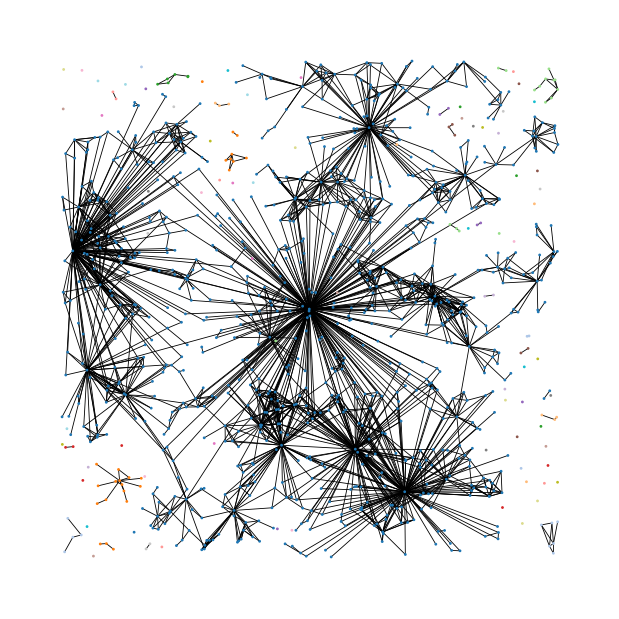

In [33]:
spa_graph = SPA.SPA(n=1_000)
spa_graph.draw()

By default, the torus edges are removed from the drawing.

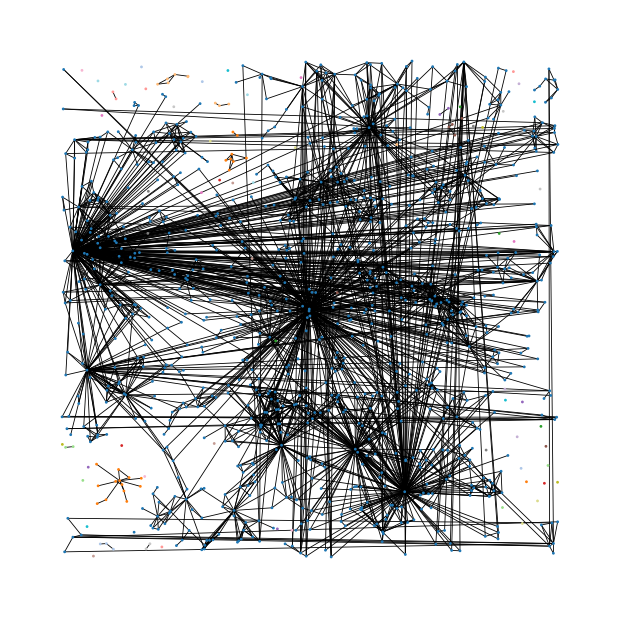

In [34]:
spa_graph.draw(show_torus_edges=True)

Some more information about the drawing tool:
- You can save your drawing by putting filename="(name)" as an input parameter
- The positions are shifted so that the first vertex is always at position (0.5, 0.5)
- Currently, drawing is only available for 2-dimensions

# Parameters

The sphere of influence of a vertex v at time t is given by (A1*deg^-(v) + A2)/t. Thus, changing A1 will affect the power law exponent of the degree sequence, and changing A2 will affect the overall density. 

A1 small:


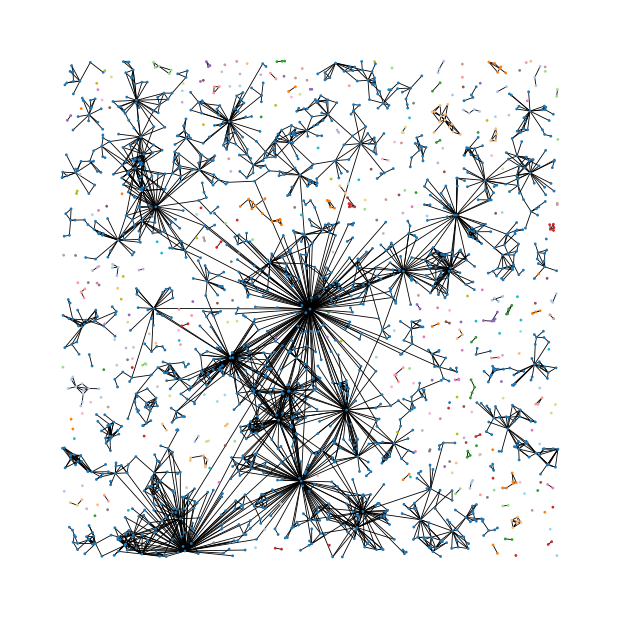

In [45]:
print('A1 small:')
SPA.SPA(n=2_000, A1=0.8).draw()

A1 large:


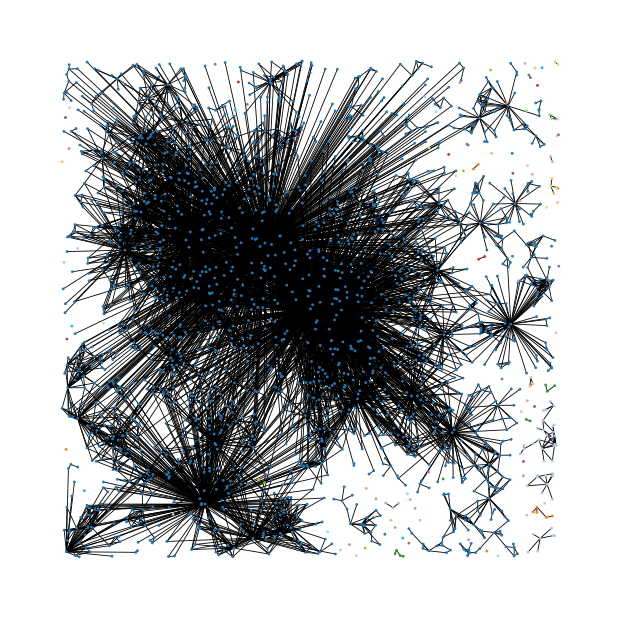

In [46]:
print("A1 large:")
SPA.SPA(n=2_000, A1=1.2).draw()

A2 small


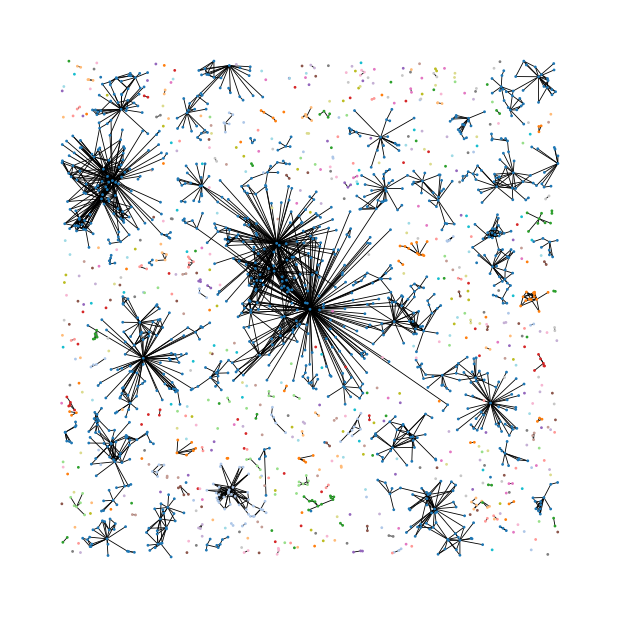

In [48]:
print("A2 small")
SPA.SPA(n=2_000, A2=0.5).draw()

A2 large


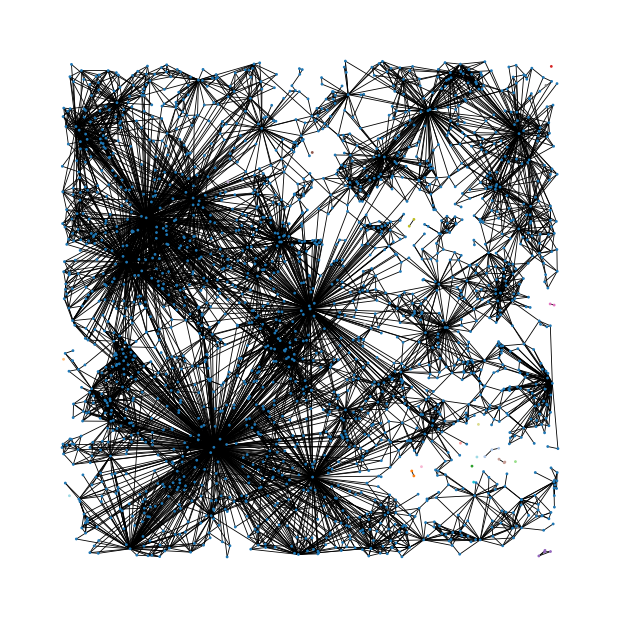

In [49]:
print("A2 large")
SPA.SPA(n=2_000, A2=2).draw()

# Progress bar

Although the model generates quite quickly, for large graphs it can still be nice to see a progress bar.

In [51]:
SPA.SPA(n=2**20, progress=True)

Building SPA: 100%|██████████| 128/128 [00:06<00:00, 19.24it/s]


SPA(n=1048576, m=3030769, dimension=2, norm=inf, backend='periodic grids')